# Student Performance Indicator — Exploratory Data Analysis

This notebook explores a dataset of 1000 students' exam results (math, reading, writing scores)
together with demographic and preparation factors, to understand **what is associated with
higher or lower test performance**.

**Life cycle followed in this notebook**
1. Understand the problem statement
2. Load and inspect the data
3. Run data-quality checks (missing values, duplicates, types)
4. Engineer a couple of useful features
5. Explore the data visually (univariate → bivariate → multivariate)
6. Summarize insights that will inform the modelling notebook


## 1. Problem Statement

We want to understand how a student's exam scores (math, reading, writing) relate to:
`gender`, `race/ethnicity`, `parental level of education`, `lunch type`, and whether the
student completed a `test preparation course`.

**Dataset:** [Students Performance in Exams](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams)
— 1000 rows, 8 columns.



## 2. Imports and Data Loading

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
%matplotlib inline


In [2]:
df = pd.read_csv('data/stud.csv')

## 3. First Look at the Data

In [3]:
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Shape: 1000 rows, 8 columns


,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


**Column reference**

| Column | Meaning |
|---|---|
| `gender` | Male / Female |
| `race_ethnicity` | Group A–E (anonymised ethnicity group) |
| `parental_level_of_education` | Highest education level of a parent |
| `lunch` | Standard or free/reduced lunch |
| `test_preparation_course` | Completed or not |
| `math_score`, `reading_score`, `writing_score` | Exam scores out of 100 |


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


## 4. Data-Quality Checks

Before drawing any conclusions we confirm the data is clean: no missing values, no duplicate rows, and sensible types.

In [5]:
missing = df.isna().sum()
print("Missing values per column:")
print(missing)
assert missing.sum() == 0, "Unexpected missing values — investigate before proceeding."
print("\n✅ No missing values.")


Missing values per column:
gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

✅ No missing values.


In [6]:
n_duplicates = df.duplicated().sum()
print(f"Duplicate rows: {n_duplicates}")


Duplicate rows: 0


In [7]:
df.nunique()


gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [8]:
df.describe()


,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


**Insight:** the three subjects have similar means (roughly 66–68) and similar spread
(std. dev. roughly 14–15), but math has a much lower minimum score than reading or writing —
a hint that math is the subject students struggle with most.

### 4.1 Numeric vs. Categorical Columns

We split columns by dtype so later plots can loop over the right group automatically.

> We use `select_dtypes` rather than the classic `dtype == 'O'` check — the `'O'` check
> silently breaks on newer pandas versions that use a dedicated string dtype instead of
> `object`, while `select_dtypes(include='number')` / `exclude='number'` always works.

In [9]:
numeric_features = df.select_dtypes(include="number").columns.tolist()
categorical_features = df.select_dtypes(exclude="number").columns.tolist()

print(f"Numerical features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")


Numerical features (3): ['math_score', 'reading_score', 'writing_score']
Categorical features (5): ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [10]:
for col in categorical_features:
    print(f"{col:32s}: {sorted(df[col].unique())}")


gender                          : ['female', 'male']
race_ethnicity                  : ['group A', 'group B', 'group C', 'group D', 'group E']
parental_level_of_education     : ["associate's degree", "bachelor's degree", 'high school', "master's degree", 'some college', 'some high school']
lunch                           : ['free/reduced', 'standard']
test_preparation_course         : ['completed', 'none']


## 5. Feature Engineering

We add a `total_score` and `average` column to summarise overall performance per student.

In [11]:
df["total_score"] = df["math_score"] + df["reading_score"] + df["writing_score"]
df["average"] = df["total_score"] / 3
df.head()


,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


### 5.1 How Many Students Hit the Extremes?

In [12]:
def score_extremes(data, column, low_threshold=20, high_score=100):
    """Count students who scored a perfect mark, and students who scored
    at or below `low_threshold`, for a given subject column."""
    full_marks = (data[column] == high_score).sum()
    low_marks = (data[column] <= low_threshold).sum()
    return full_marks, low_marks


subject_cols = ["math_score", "reading_score", "writing_score"]
summary = pd.DataFrame(
    {col: score_extremes(df, col) for col in subject_cols},
    index=["full_marks", f"<=20_marks"],
).T
summary


,full_marks,<=20_marks
math_score,7,4
reading_score,17,1
writing_score,14,3


**Insight:** students perform worst in math (most low scores, fewest perfect scores) and
best in reading — consistent with the low minimum we saw in `describe()` above.

## 6. Visual Exploration

We go from **univariate** (one variable at a time) to **bivariate** (two variables) to
**multivariate** (several variables together) analysis.

### 6.1 Distribution of Overall Performance

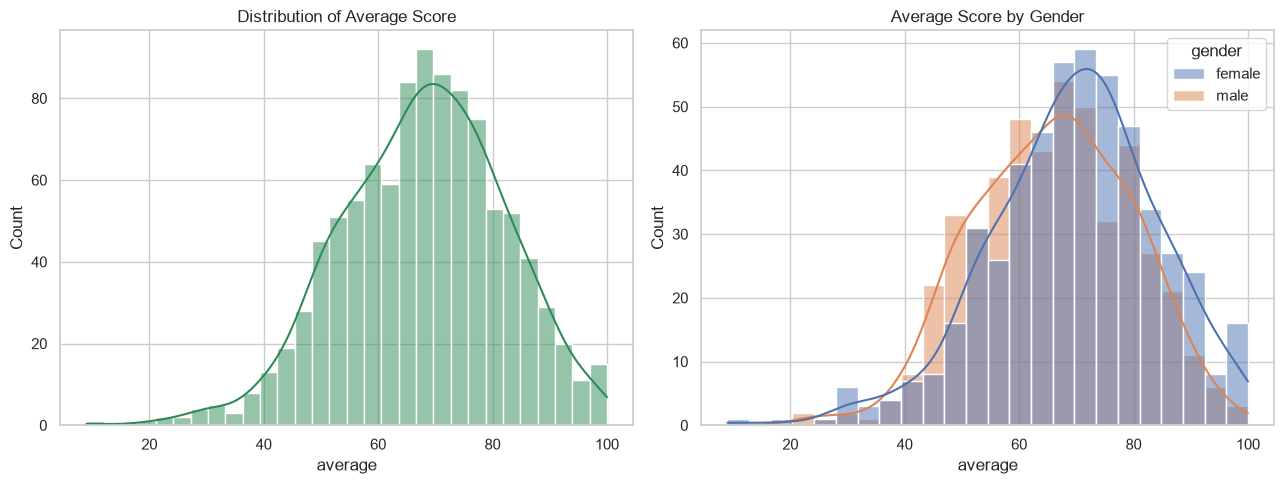

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(data=df, x="average", bins=30, kde=True, color="seagreen", ax=axes[0])
axes[0].set_title("Distribution of Average Score")

sns.histplot(data=df, x="average", kde=True, hue="gender", ax=axes[1])
axes[1].set_title("Average Score by Gender")

plt.tight_layout()
plt.show()


**Insight:** the average score is roughly bell-shaped (centered around 65–70). Splitting by gender, female students' distribution sits slightly to the right of male students' — female students tend to score a bit higher on average.

### 6.2 Effect of Lunch Type

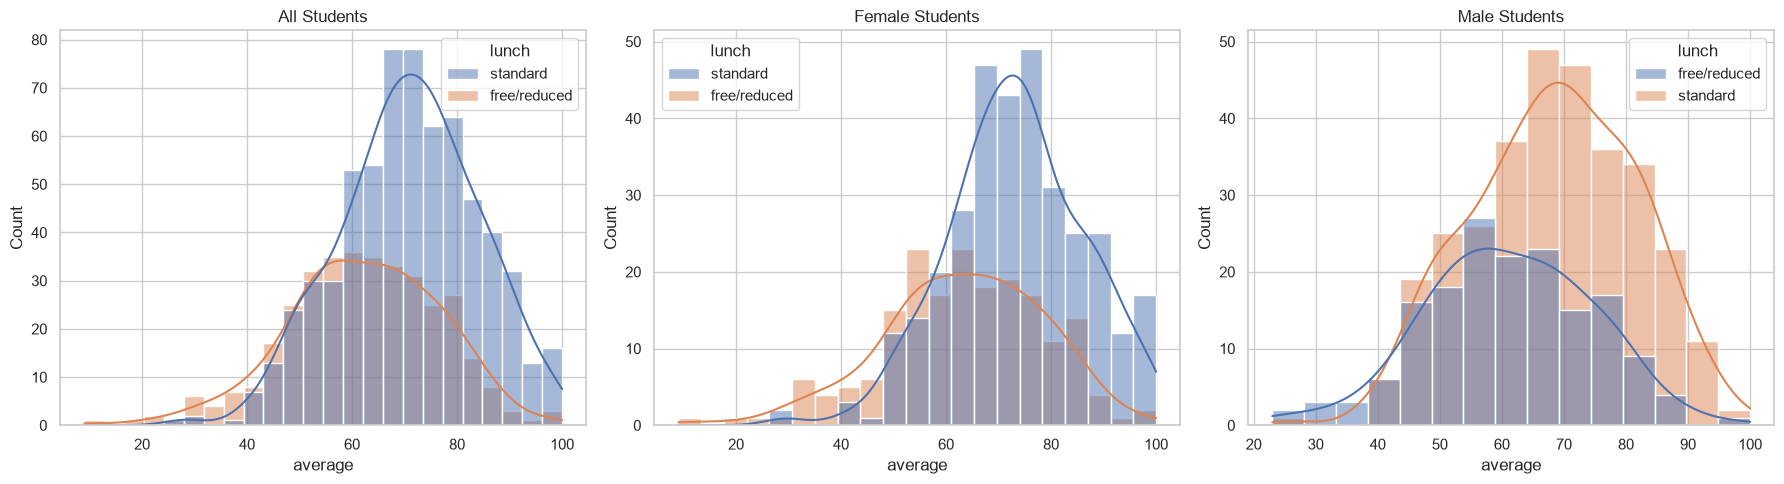

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(data=df, x="average", kde=True, hue="lunch", ax=axes[0])
axes[0].set_title("All Students")

sns.histplot(data=df[df.gender == "female"], x="average", kde=True, hue="lunch", ax=axes[1])
axes[1].set_title("Female Students")

sns.histplot(data=df[df.gender == "male"], x="average", kde=True, hue="lunch", ax=axes[2])
axes[2].set_title("Male Students")

plt.tight_layout()
plt.show()


**Insight:** standard lunch is associated with higher average scores than free/reduced lunch, for both genders — plausibly a proxy for socio-economic background rather than lunch itself.

### 6.3 Effect of Parental Education

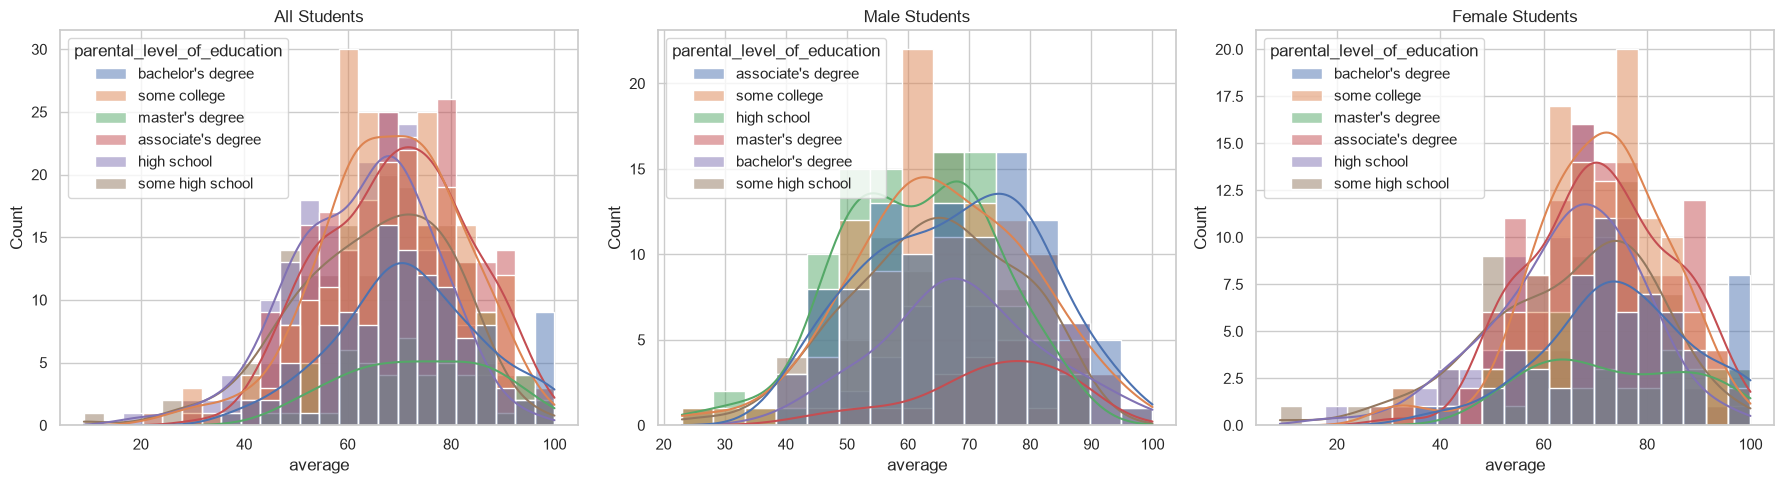

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, subset, title in zip(
    axes,
    [df, df[df.gender == "male"], df[df.gender == "female"]],
    ["All Students", "Male Students", "Female Students"],
):
    sns.histplot(data=subset, x="average", kde=True, hue="parental_level_of_education", ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.show()


**Insight:** parental education has only a mild overall effect; where it shows up most is among male students whose parents hold an associate's or master's degree, who tend to score somewhat higher.

### 6.4 Effect of Race/Ethnicity Group

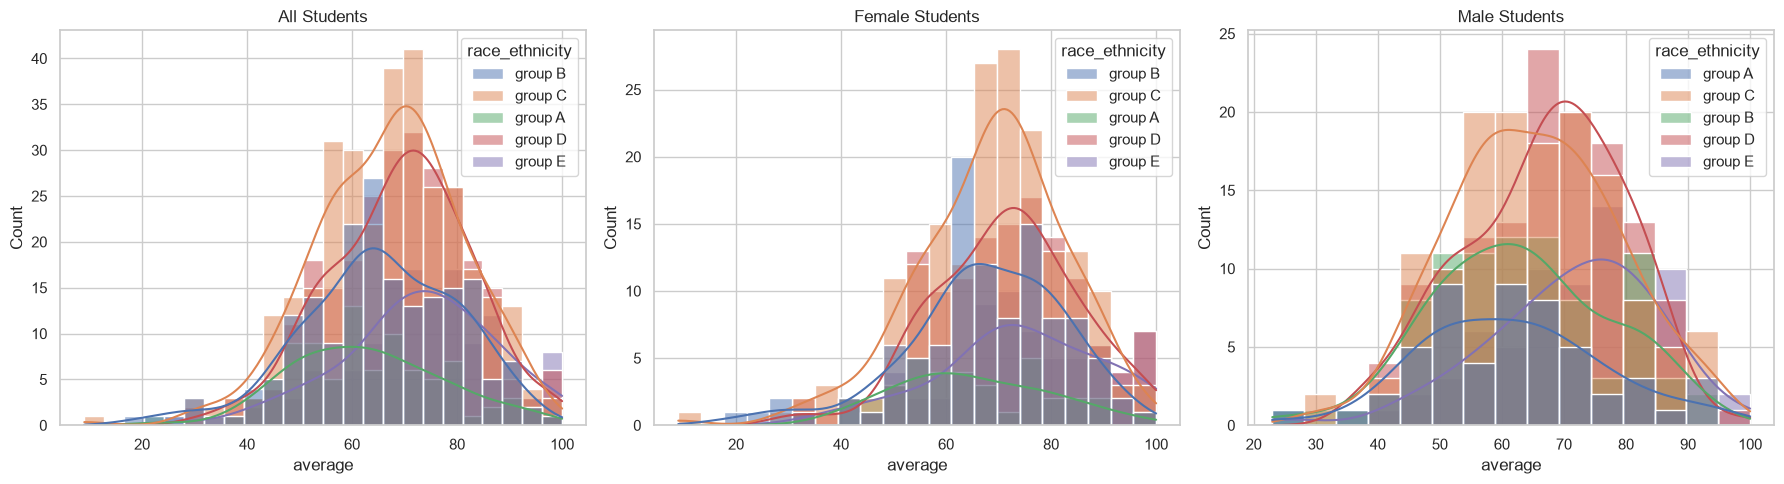

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, subset, title in zip(
    axes,
    [df, df[df.gender == "female"], df[df.gender == "male"]],
    ["All Students", "Female Students", "Male Students"],
):
    sns.histplot(data=subset, x="average", kde=True, hue="race_ethnicity", ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.show()


**Insight:** groups A and B tend to score lower than groups C–E, consistently across genders.

### 6.5 Score Spread per Subject

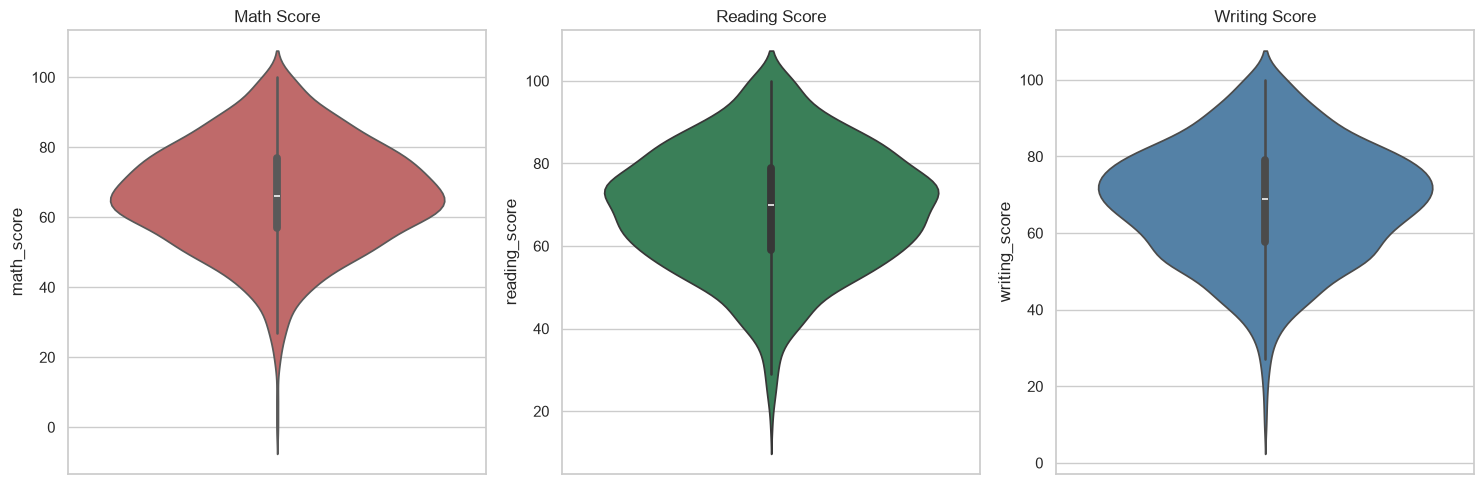

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ["indianred", "seagreen", "steelblue"]
for ax, col, color in zip(axes, subject_cols, colors):
    sns.violinplot(y=df[col], color=color, ax=ax)
    ax.set_title(col.replace("_", " ").title())

plt.tight_layout()
plt.show()


**Insight:** most students score 60–80 in math, while reading and writing scores spread a bit wider, roughly 50–80.

### 6.6 Category Shares (Pie Charts)

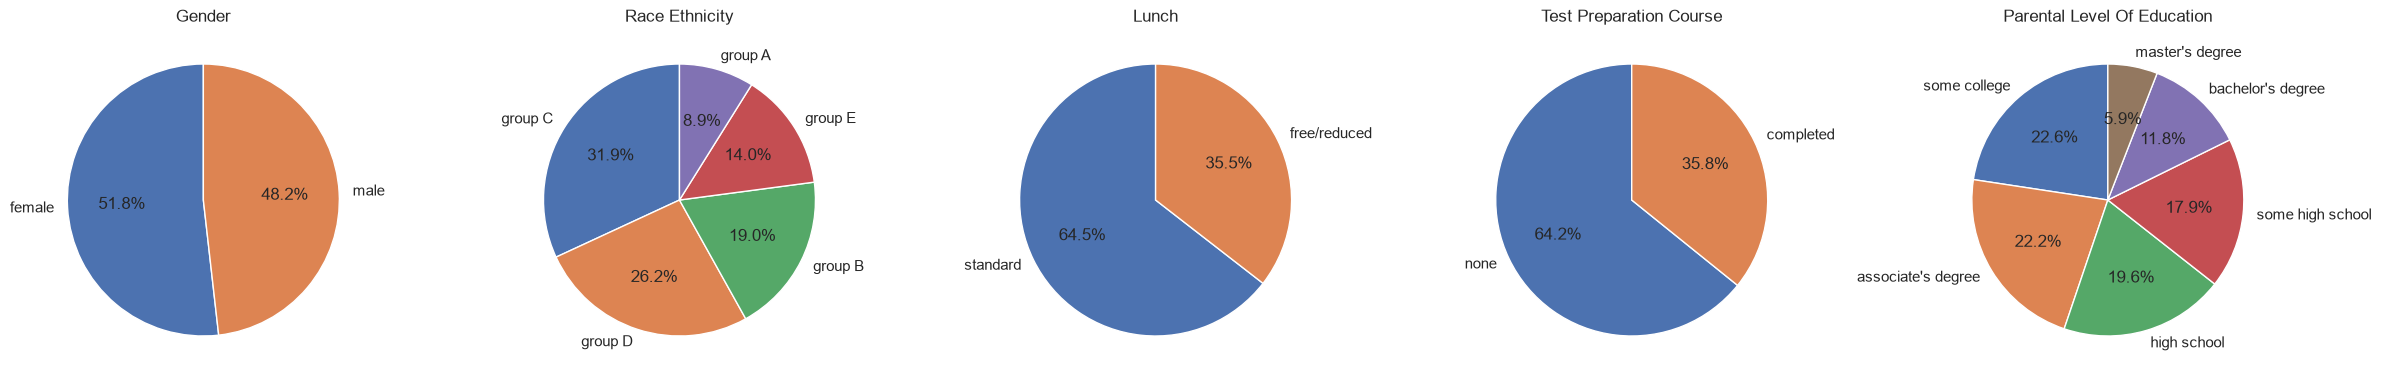

In [18]:
fig, axes = plt.subplots(1, 5, figsize=(24, 5))
pie_columns = [
    "gender", "race_ethnicity", "lunch",
    "test_preparation_course", "parental_level_of_education",
]
for ax, col in zip(axes, pie_columns):
    counts = df[col].value_counts()
    ax.pie(counts.values, labels=counts.index, autopct="%1.1f%%", startangle=90)
    ax.set_title(col.replace("_", " ").title())

plt.tight_layout()
plt.show()


**Insight:**
- Gender is close to balanced.
- Group C is the largest ethnicity group.
- More students have standard lunch than free/reduced.
- More students have *not* completed a test-preparation course than have.


### 6.7 Count Plots with Labelled Bars

A small helper avoids repeating the same count-plot / bar-label boilerplate for every categorical column.

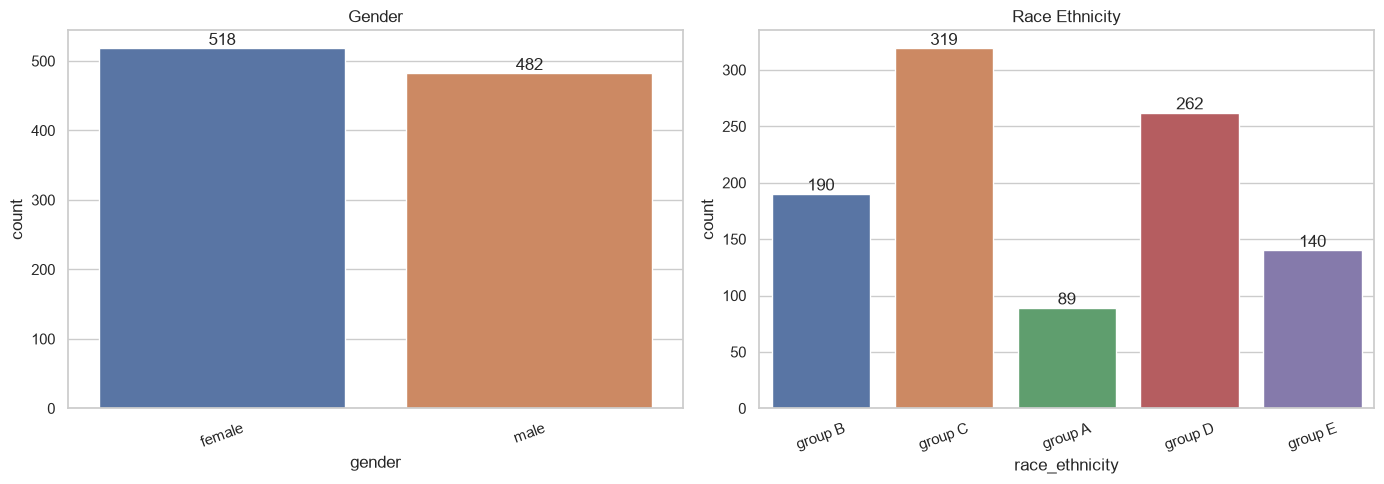

In [19]:
def labelled_countplot(data, column, ax, title=None):
    sns.countplot(x=column, data=data, hue=column, legend=False, ax=ax)
    for container in ax.containers:
        ax.bar_label(container)
    ax.set_title(title or column.replace("_", " ").title())
    ax.tick_params(axis="x", rotation=20)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labelled_countplot(df, "gender", axes[0])
labelled_countplot(df, "race_ethnicity", axes[1])
plt.tight_layout()
plt.show()


### 6.8 Gender vs. Subject Averages

In [20]:
gender_group = df.groupby("gender")[numeric_features + ["average"]].mean()
gender_group


,math_score,reading_score,writing_score,average
gender,,,,
female,63.633205,72.608108,72.467181,69.569498
male,68.728216,65.473029,63.311203,65.837483


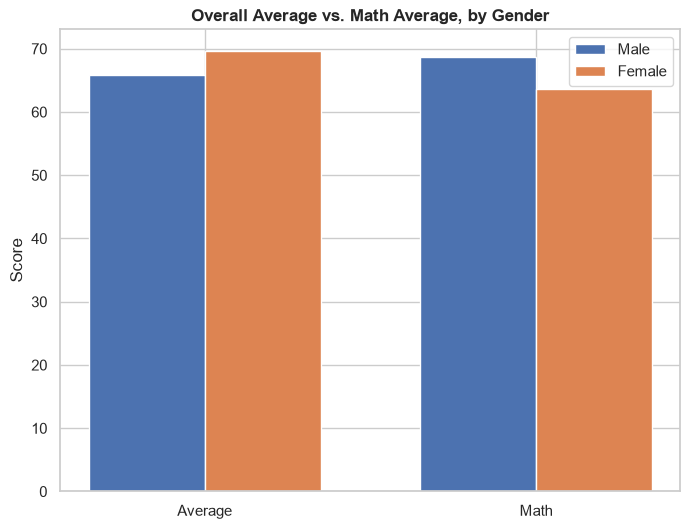

In [21]:
x_labels = ["Average", "Math"]
male_scores = [gender_group.loc["male", "average"], gender_group.loc["male", "math_score"]]
female_scores = [gender_group.loc["female", "average"], gender_group.loc["female", "math_score"]]

x = np.arange(len(x_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(x - width / 2, male_scores, width, label="Male")
ax.bar(x + width / 2, female_scores, width, label="Female")
ax.set_xticks(x, x_labels)
ax.set_ylabel("Score")
ax.set_title("Overall Average vs. Math Average, by Gender", fontweight="bold")
ax.legend()
plt.show()


**Insight:** females lead on overall average, but males score slightly higher in math specifically.

### 6.9 Race/Ethnicity vs. Subject Scores

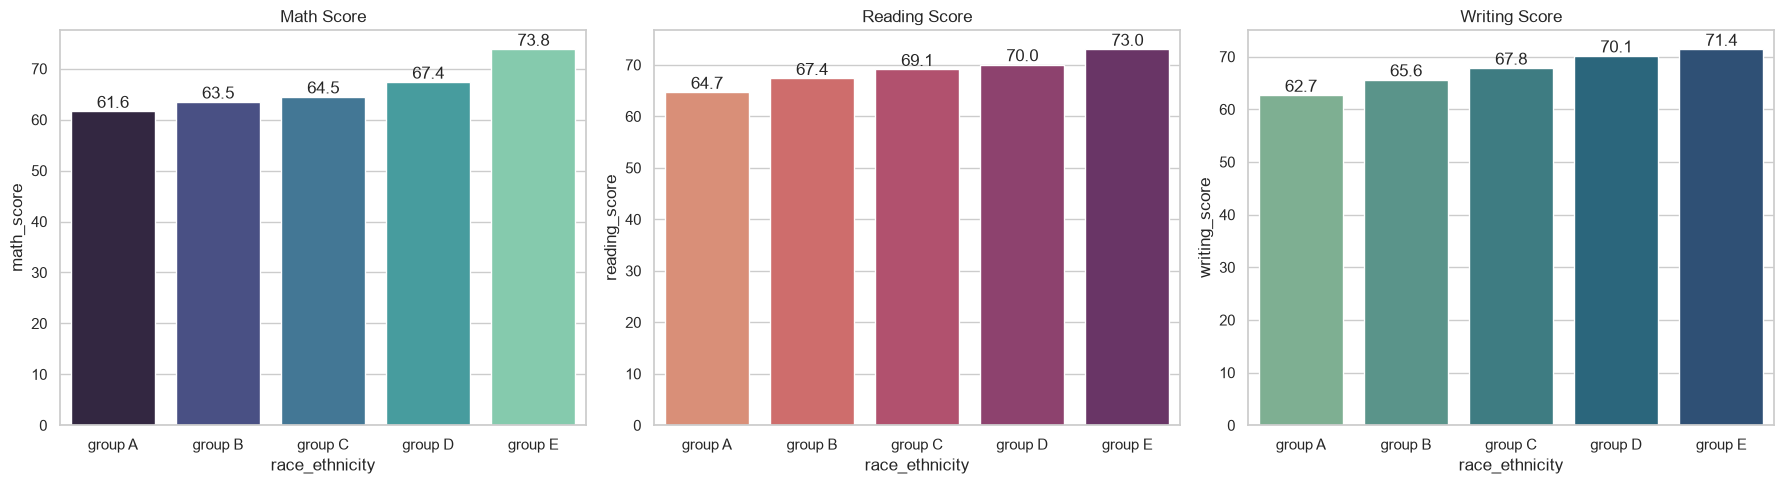

In [22]:
group_means = df.groupby("race_ethnicity")[subject_cols].mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palettes = ["mako", "flare", "crest"]
for ax, col, palette in zip(axes, subject_cols, palettes):
    order = group_means.index
    sns.barplot(x=order, y=group_means[col], hue=order, palette=palette, legend=False, ax=ax)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f")
    ax.set_title(col.replace("_", " ").title())

plt.tight_layout()
plt.show()


**Insight:** group E scores highest and group A scores lowest across all three subjects.

### 6.10 Parental Education vs. Scores

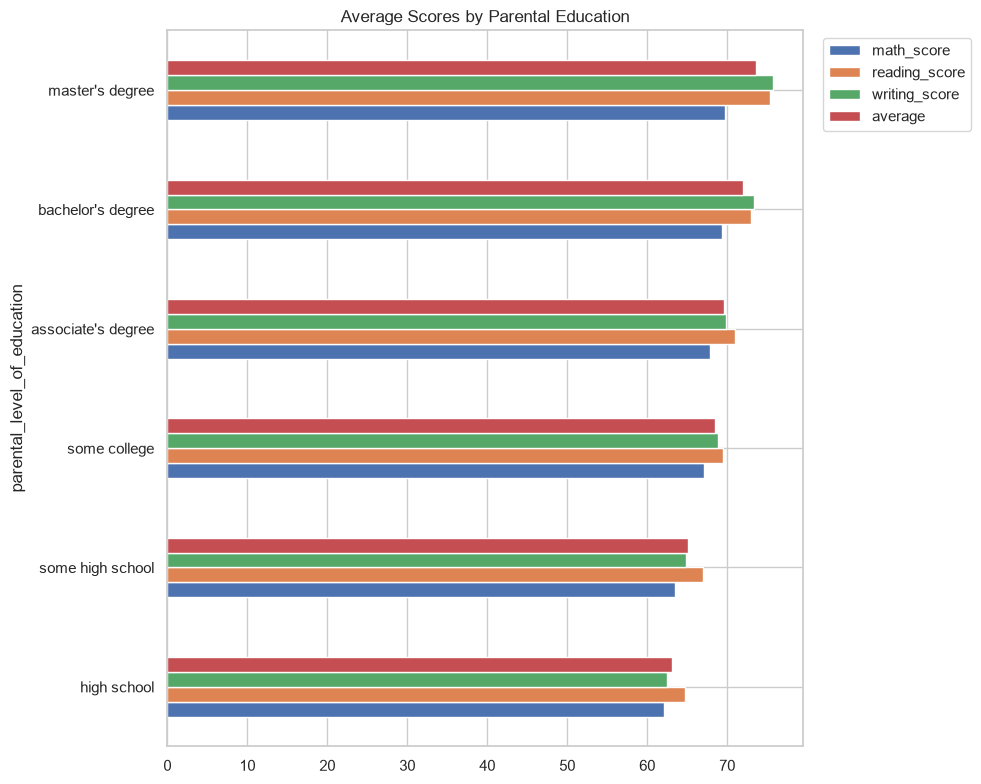

In [23]:
df.groupby("parental_level_of_education")[numeric_features + ["average"]].mean().sort_values("average").plot(
    kind="barh", figsize=(10, 8)
)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.title("Average Scores by Parental Education")
plt.tight_layout()
plt.show()


**Insight:** students whose parents hold a bachelor's or master's degree score highest, on average.

### 6.11 Lunch and Test Prep Together

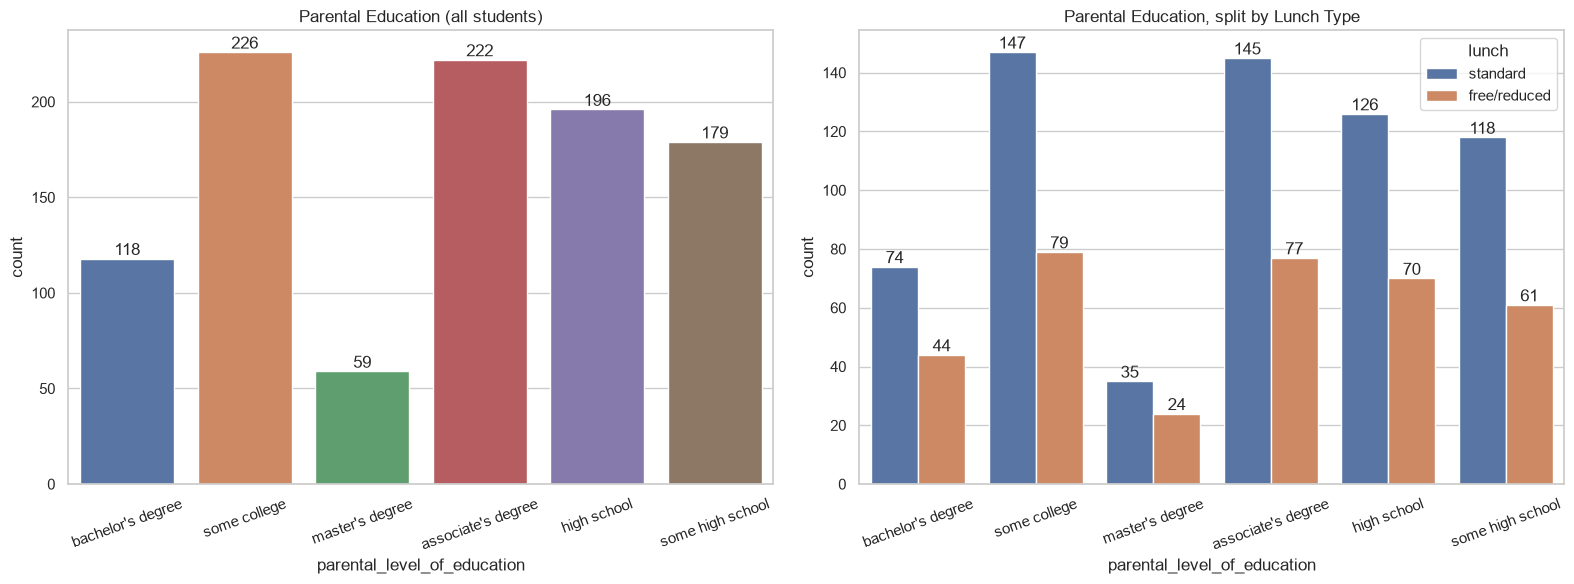

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
labelled_countplot(
    df.assign(**{"test_preparation_course": df["test_preparation_course"]}),
    "parental_level_of_education", axes[0], "Parental Education (all students)"
)
sns.countplot(
    x="parental_level_of_education", data=df, hue="lunch", ax=axes[1]
)
for container in axes[1].containers:
    axes[1].bar_label(container)
axes[1].set_title("Parental Education, split by Lunch Type")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


### 6.12 Test Preparation Course vs. Scores

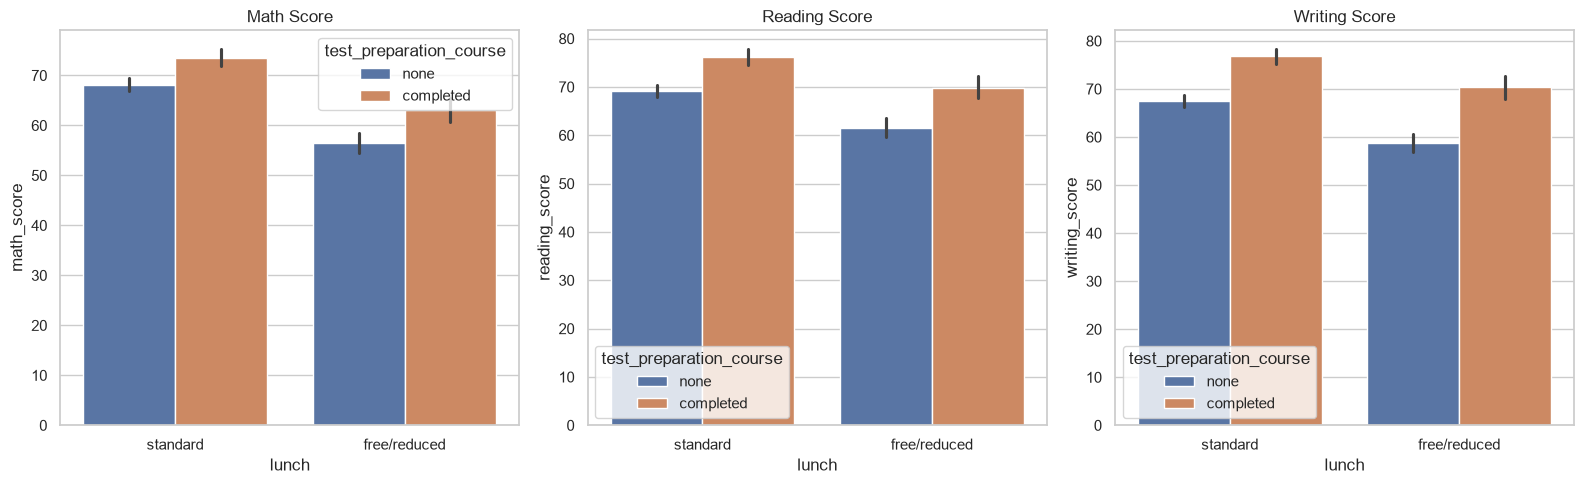

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, subject_cols):
    sns.barplot(x="lunch", y=col, hue="test_preparation_course", data=df, ax=ax)
    ax.set_title(col.replace("_", " ").title())

plt.tight_layout()
plt.show()


**Insight:** students who completed the test-preparation course outscore those who didn't, in every subject and regardless of lunch type.

### 6.13 Outlier Check

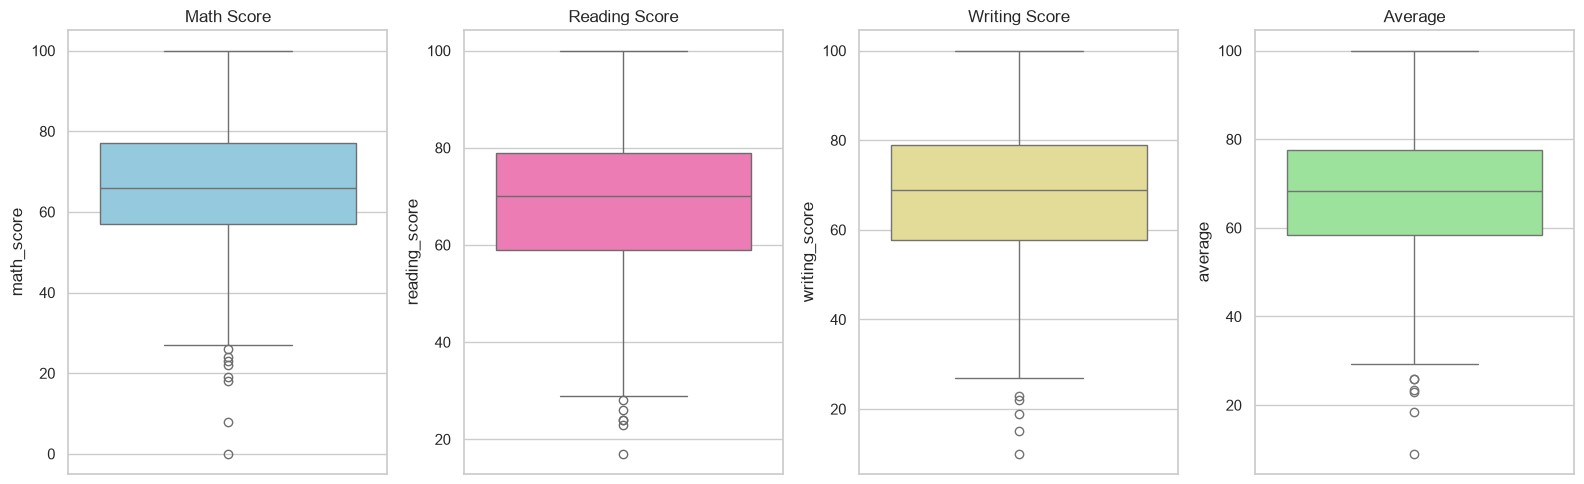

In [26]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, col, color in zip(axes, subject_cols + ["average"], ["skyblue", "hotpink", "khaki", "lightgreen"]):
    sns.boxplot(y=df[col], color=color, ax=ax)
    ax.set_title(col.replace("_", " ").title())

plt.tight_layout()
plt.show()


### 6.14 Correlations Between Scores

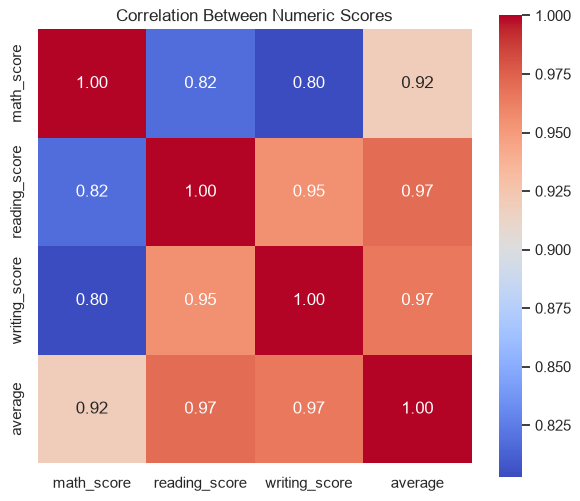

In [27]:
corr = df[numeric_features + ["average"]].corr()
plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Between Numeric Scores")
plt.show()


**Insight:** the three subject scores are strongly positively correlated (roughly 0.8–0.85) — a student who does well in one subject tends to do well in the others.

### 6.15 Multivariate View (Pairplot)

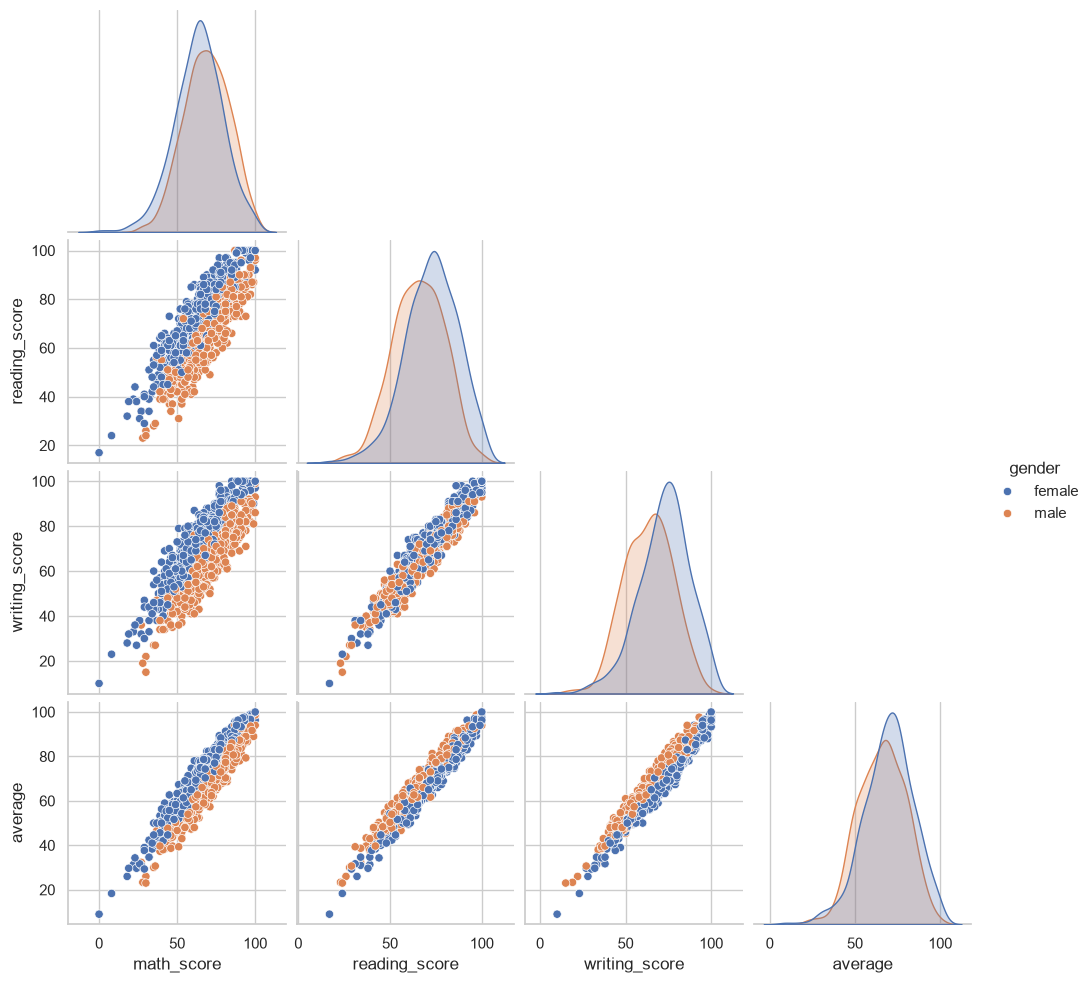

In [28]:
sns.pairplot(df[subject_cols + ["average", "gender"]], hue="gender", corner=True)
plt.show()


**Insight:** all three scores increase roughly linearly with each other, reinforcing the correlation heatmap above.

## 7. Conclusions

- Performance is associated with **lunch type**, **race/ethnicity group**, and **parental
  education level** — likely proxies for socio-economic background.
- **Female students** lead in overall average score and in pass rate; **male students**
  score marginally higher specifically in math.
- **Test preparation course completion** consistently improves scores in every subject —
  of the factors examined, it's the one most directly under a student's control.
- The three subject scores are highly correlated, so a single "average" or "total" score is
  a reasonable summary metric for modelling.

These insights carry over directly into the next notebook, where we build models to predict
a student's math score from the other variables.
